# Use Case: Real-Time Emotion Detection on Social Media Posts (tweets)

### Problem Statement
Traditional sentiment analysis (positive/negative/neutral) is too coarse to understand how users truly feel on social media. Tweets often express complex human emotions such as sadness, anger, fear, love, or surprise—especially during product launches, crises, or public events.

Organizations need deeper emotional insights to:

  - Detect early signs of customer frustration or distress

  - Understand emotional drivers behind engagement

  - Respond empathetically rather than generically

### Objective

**Use a fine-tuned BERT model with a custom multi-class classification head** to automatically detect specific emotions expressed in tweets and enable emotionally aware decision-makin

# Install Required Libraries

In [2]:
!pip install -U transformers
!pip install -U accelerate
!pip install -U datasets
!pip install -U bertviz
!pip install -U umap-learn
!pip install seaborn --upgrade
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 512.3/512.3 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 51.9 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 142.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 85.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.6 MB/s eta 0:00:00


In [3]:
import transformers
print(transformers.__version__)

4.57.3


# Define Parameters

In [4]:
model_ckpt    = "bert-base-uncased"
data_file     = "https://raw.githubusercontent.com/laxmimerit/All-CSV-ML-Data-Files-Download/master/twitter_multi_class_sentiment.csv"
ft_model_name = "bert-base-uncased-tweet-sentiment-analysis"
training_dir  = "./checkpoints"
hf_repo_id    = f"mishrabp/{ft_model_name}"


# Data Analysis

In [5]:
import pandas as pd

df = pd.read_csv(data_file)
df.head(5)

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        16000 non-null  object
 1   label       16000 non-null  int64 
 2   label_name  16000 non-null  object
dtypes: int64(1), object(2)
memory usage: 375.1+ KB


In [7]:
df.isnull().sum()

,0
text,0
label,0
label_name,0


In [8]:
df.describe()

,label
count,16000.000000
mean,1.565937
std,1.501430
min,0.000000
25%,0.000000
50%,1.000000
75%,3.000000
max,5.000000


In [9]:
df['label'].value_counts()

,count
label,
1,5362
0,4666
3,2159
4,1937
2,1304
5,572


In [10]:
import matplotlib.pyplot as plt

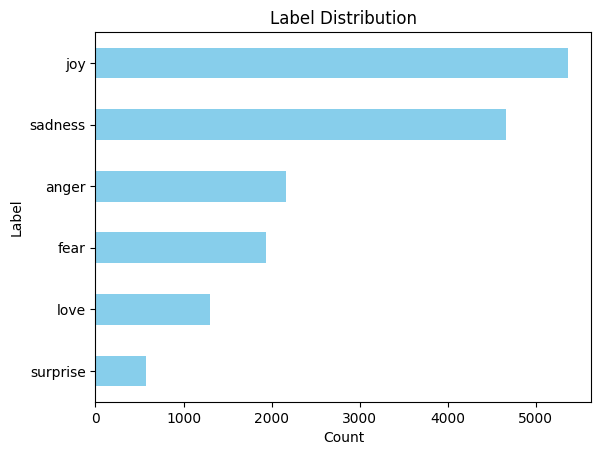

In [11]:
label_counts=df['label_name'].value_counts(ascending=True)
label_counts.plot(kind='barh', color='skyblue')
plt.xlabel('Count')
plt.ylabel('Label')
plt.title('Label Distribution')
plt.show()

<Axes: title={'center': 'words_per_tweet'}, xlabel='label_name'>

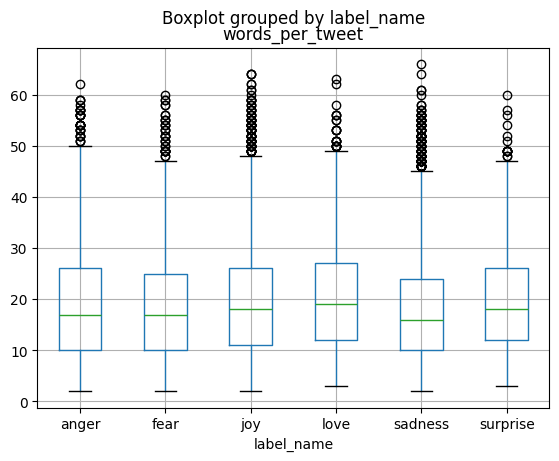

In [12]:
df['words_per_tweet'] = df['text'].apply(lambda x: len(x.split()))
df.boxplot("words_per_tweet", by="label_name")

This tells you that:
- maximum no of tweets falls into joy and sadness category
- mean word counts in each category are more and less the same. (look at the green line in the box)

# Data Preprocessing

### Define Dataset

In [13]:
# train, validation and test split
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label'])
train.shape, test.shape

test, validation = train_test_split(test, test_size=1/3, random_state=42, stratify=test['label'])
train.shape, validation.shape, test.shape

((11200, 4), (1600, 4), (3200, 4))

In [14]:
from datasets import Dataset, DatasetDict

dataset = DatasetDict({
    'train': Dataset.from_pandas(train, preserve_index=False),
    'test': Dataset.from_pandas(test, preserve_index=False),
    'validation': Dataset.from_pandas(validation, preserve_index=False)
})
dataset


DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_name', 'words_per_tweet'],
        num_rows: 11200
    })
    test: Dataset({
        features: ['text', 'label', 'label_name', 'words_per_tweet'],
        num_rows: 3200
    })
    validation: Dataset({
        features: ['text', 'label', 'label_name', 'words_per_tweet'],
        num_rows: 1600
    })
})

In [15]:
dataset['train'][0]

{'text': 'i can remember a year ago yesterday feeling so unsure so scared of what our future held',
 'label': 4,
 'label_name': 'fear',
 'words_per_tweet': 17}

### Tokenization of Text

In [16]:
# load the base model tokenizer

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

encoded_text= tokenizer("I love nlp learning! Tokenization awesome!!")
print(encoded_text)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

{'input_ids': [101, 1045, 2293, 17953, 2361, 4083, 999, 19204, 3989, 12476, 999, 999, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [17]:
len(tokenizer.vocab), tokenizer.vocab_size, tokenizer.model_max_length

(30522, 30522, 512)

In [18]:
# define tokenization method
def tokenize_fn(batch):
  return tokenizer(batch['text'], truncation=True, padding=True)

print(tokenize_fn(dataset['train'][:2]))

{'input_ids': [[101, 1045, 2064, 3342, 1037, 2095, 3283, 7483, 3110, 2061, 12422, 2061, 6015, 1997, 2054, 2256, 2925, 2218, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 10047, 1037, 7089, 1998, 1037, 19373, 1045, 2074, 12731, 20338, 1998, 4952, 1998, 1045, 2064, 2102, 2079, 1996, 12731, 20338, 2518, 2061, 1045, 2514, 1037, 2978, 2862, 3238, 102]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}


In [19]:
# tokenize the text
emotion_encoded = dataset.map(tokenize_fn, batched=True, batch_size=None)
emotion_encoded

Map:   0%|          | 0/11200 [00:00<?, ? examples/s]

Map:   0%|          | 0/3200 [00:00<?, ? examples/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_name', 'words_per_tweet', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 11200
    })
    test: Dataset({
        features: ['text', 'label', 'label_name', 'words_per_tweet', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3200
    })
    validation: Dataset({
        features: ['text', 'label', 'label_name', 'words_per_tweet', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1600
    })
})

In [20]:
# define label2id, id2label
label2id = {x['label_name']:x['label'] for x in dataset['train']}
id2label = {v:k for k,v in label2id.items()}
label2id, id2label

({'fear': 4, 'sadness': 0, 'joy': 1, 'surprise': 5, 'anger': 3, 'love': 2},
 {4: 'fear', 0: 'sadness', 1: 'joy', 5: 'surprise', 3: 'anger', 2: 'love'})

# Build Model

In [21]:
# Download the base BERT model and check its architecture
from transformers import AutoModel
import torch

model = AutoModel.from_pretrained(model_ckpt)
model.config.architectures, model.config.hidden_size, model.config.num_hidden_layers, model.config.id2label

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

(['BertForMaskedLM'], 768, 12, {0: 'LABEL_0', 1: 'LABEL_1'})

In [22]:
# Check the model architecture.
# You can see there is no "Classification Header" in the base model
model

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

In [23]:
# Let's add a "Classification Header" that could generate the expected emotion
from transformers import AutoModelForSequenceClassification, AutoConfig

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_labels = len(label2id)

# adds the header with expected classification output
config = AutoConfig.from_pretrained(model_ckpt, label2id=label2id, id2label=id2label)

model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, config=config).to(device)

# You could see here, it has added a classification header with 6 classes.
model


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [24]:
config

BertConfig {
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "sadness",
    "1": "joy",
    "2": "love",
    "3": "anger",
    "4": "fear",
    "5": "surprise"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "label2id": {
    "anger": 3,
    "fear": 4,
    "joy": 1,
    "love": 2,
    "sadness": 0,
    "surprise": 5
  },
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "transformers_version": "4.57.3",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

# Define Trainer and Evaluator

In [25]:
# !pip uninstall transformers -y
# !pip install transformers==4.57.3 --upgrade

In [26]:
from transformers import TrainingArguments

# Hyper parameters
batch_size    = 64
epochs        = 2
learning_rate = 2e-5

# Training Arguments
training_args = TrainingArguments( output_dir=training_dir,
                                  overwrite_output_dir = True,
                                  num_train_epochs = epochs,
                                  learning_rate = learning_rate,
                                  per_device_train_batch_size = batch_size,
                                  per_device_eval_batch_size = batch_size,
                                  gradient_accumulation_steps=1,
                                  weight_decay = 0.01,
                                  disable_tqdm = False,
                                  logging_steps = 50,
                                  max_steps=300,
                                  report_to="none")

In [27]:
# Build compute metrics function
import evaluate
import numpy as np

accuracy = evaluate.load("accuracy")

def compute_metrics_evaluate(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)


In [28]:
# use sklearn to build compute metrics
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    f1 = f1_score(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)

    return {"accuracy": acc, "f1": f1}

# Train Model

In [29]:
from transformers import Trainer

trainer = Trainer(model=model, args=training_args,
                  compute_metrics=compute_metrics,
                  train_dataset = emotion_encoded['train'],
                  eval_dataset = emotion_encoded['validation'],
                  tokenizer = tokenizer)

/tmp/ipython-input-1591179924.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=model, args=training_args,


In [30]:
trainer.train()

Step,Training Loss
50,1.545300
100,1.064000
150,0.736400
200,0.516400
250,0.397900
300,0.367400


TrainOutput(global_step=300, training_loss=0.7712364959716796, metrics={'train_runtime': 65.2055, 'train_samples_per_second': 294.454, 'train_steps_per_second': 4.601, 'total_flos': 858430647014400.0, 'train_loss': 0.7712364959716796, 'epoch': 1.7142857142857144})

# Evaluate Finetuned Model

In [31]:
# Evaluate against the test data
preds_output = trainer.predict(emotion_encoded['test'])
preds_output.metrics

{'test_loss': 0.318125456571579,
 'test_accuracy': 0.903125,
 'test_f1': 0.9026144460844641,
 'test_runtime': 3.0748,
 'test_samples_per_second': 1040.713,
 'test_steps_per_second': 16.261}

In [32]:
y_pred = np.argmax(preds_output.predictions, axis=1)
y_true = emotion_encoded['test'][:]['label']

In [33]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94       933
           1       0.92      0.92      0.92      1072
           2       0.78      0.75      0.76       261
           3       0.90      0.92      0.91       432
           4       0.87      0.88      0.88       387
           5       0.86      0.75      0.80       115

    accuracy                           0.90      3200
   macro avg       0.88      0.86      0.87      3200
weighted avg       0.90      0.90      0.90      3200



In [34]:
# plot confusion matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

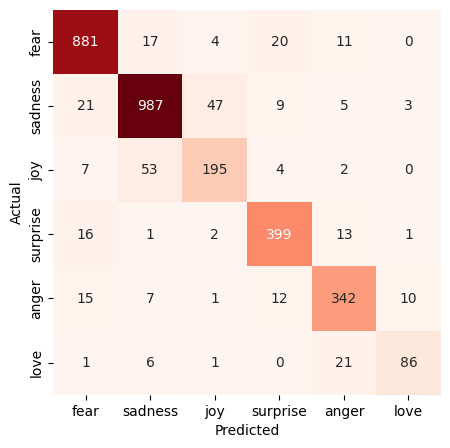

In [35]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, xticklabels=label2id.keys(), yticklabels=label2id.keys(), fmt='d', cbar=False, cmap='Reds')
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# Inference Model

In [36]:
text = "I am super happy today. I got it done. Finally!!"

def get_prediction(text):
    input_encoded = tokenizer(text, return_tensors='pt').to(device)

    with torch.no_grad():
        outputs = model(**input_encoded)

    logits = outputs.logits

    pred = torch.argmax(logits, dim=1).item()
    return id2label[pred]

get_prediction(text)

'joy'

In [37]:
# saves the model to your local filesystem
trainer.save_model(ft_model_name)
tokenizer.save_pretrained(ft_model_name)

('bert-base-uncased-tweet-sentiment-analysis/tokenizer_config.json',
 'bert-base-uncased-tweet-sentiment-analysis/special_tokens_map.json',
 'bert-base-uncased-tweet-sentiment-analysis/vocab.txt',
 'bert-base-uncased-tweet-sentiment-analysis/added_tokens.json',
 'bert-base-uncased-tweet-sentiment-analysis/tokenizer.json')

In [38]:
from transformers import pipeline

# use the model that is already saved locally
classifier = pipeline('text-classification', model= ft_model_name)

classifier([text, 'hello, how are you?', "love you", "i am feeling low"])

Device set to use cuda:0


[{'label': 'joy', 'score': 0.9297134280204773},
 {'label': 'joy', 'score': 0.6197832226753235},
 {'label': 'love', 'score': 0.5415583848953247},
 {'label': 'sadness', 'score': 0.9593217968940735}]

# Push the Model to Hugging Face

In [39]:
# Install required library
!pip install huggingface_hub --quiet

### Create the README.md file

In [40]:
from pathlib import Path
from IPython.display import FileLink, display

# Model directory
MODEL_DIR = Path(ft_model_name)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# README content
readme_content = """
---
library_name: transformers
tags: [sentiment-analysis, BERT, social-media, emotion-detection]
---

# BERT Tweet Sentiment Analysis

## Model Details

### Model Description
This model is a BERT-based transformer (`bert-base-uncased`) fine-tuned for sentiment analysis on tweets. It classifies text into six emotion categories: sadness, joy, love, anger, fear, and surprise. The model was trained with a custom classification head on tweet data to capture short-form, social media style text.

- **Developed by:** Bibhu Mishra
- **Model type:** Sequence Classification
- **Language(s) (NLP):** English
- **License:** MIT
- **Finetuned from model:** bert-base-uncased

### Model Sources
- **Repository:** [Hugging Face Model Hub](https://huggingface.co/mishrabp/bert-base-uncased-tweet-sentiment-analysis)

## Uses

### Direct Use
This model can be used to classify tweets or short text into emotions, useful for social listening, customer sentiment analysis, and marketing insights.

### Downstream Use
The model can be integrated into larger NLP pipelines, such as real-time social media monitoring dashboards, chatbots, or recommendation systems that require sentiment-aware behavior.

### Out-of-Scope Use
- Not suitable for clinical, medical, or diagnostic use.
- Performance may decrease on very long text, sarcasm, or highly domain-specific language.

## Bias, Risks, and Limitations
- Limited to English-language social media text.
- May misclassify sarcastic or context-heavy tweets.
- Emotions are simplified into six categories, which may not capture nuanced sentiment.

### Recommendations
Use this model for **exploratory sentiment analytics** and not for critical decisions. Always review predictions in the context of business requirements.

## How to Get Started with the Model

```python
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

model_name = "mishrabp/bert-base-uncased-tweet-sentiment-analysis"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

classifier = pipeline("text-classification", model=model, tokenizer=tokenizer)

tweets = [
    "I love spending time with my friends!",
    "I feel so sad about the news today."
]

results = classifier(tweets)
print(results)
```

#### Output
```json
[
    {"label": "love", "score": 0.95},
    {"label": "sadness", "score": 0.88}
]

```

### Labels
```
| ID | Emotion  |
| -- | -------- |
| 0  | sadness  |
| 1  | joy      |
| 2  | love     |
| 3  | anger    |
| 4  | fear     |
| 5  | surprise |
```

### Inference URL
https://mishrabp-twitter-sentiment-analysis.hf.space/

"""

# Write README.md
readme_path = MODEL_DIR / "README.md"
readme_path.write_text(readme_content, encoding="utf-8")

# Display download link
print("README.md created successfully.")
display(FileLink(readme_path))


README.md created successfully.


/content/bert-base-uncased-tweet-sentiment-analysis/README.md

### Upload

In [41]:
from huggingface_hub import HfApi, upload_folder, Repository
import os
import shutil
from google.colab import userdata
from pathlib import Path

# --- Variables ---
hf_token = userdata.get("HF_TOKEN_WRITE")  # Ensure your HF_TOKEN is set
hf_username = "mishrabp"
repo_name = "bert-base-uncased-tweet-sentiment-analysis"
hf_repo_id = f"{hf_username}/{repo_name}"
model_source_dir = f"{ft_model_name}"  # Folder with your model, tokenizer, config, README.md
upload_dir = f"{ft_model_name}/hf_upload"              # Temp folder to push repo

# --- 1️⃣ Create the repo if it doesn't exist ---
api = HfApi()
try:
    api.create_repo(repo_id=hf_repo_id, token=hf_token, private=False)
    print(f"Repo created: {hf_repo_id}")
except Exception as e:
    print(f"Repo may already exist: {e}")

Repo may already exist: 409 Client Error: Conflict for url: https://huggingface.co/api/repos/create (Request ID: Root=1-69556fb9-6b5e66a4220a76a86723cf55;37677829-f48d-492e-b921-4d24c9ccfad4)

You already created this model repo: mishrabp/bert-base-uncased-tweet-sentiment-analysis


In [ ]:
# # --- 1️⃣ Create fresh upload_dir ---
# Path(upload_dir).mkdir(exist_ok=True)
# print(f"Created folder: {upload_dir}")
if Path(upload_dir).exists():
    print(f"Folder already exists: {upload_dir}")
else:
    print(f"Folder does not exist: {upload_dir}")
    Path(upload_dir).mkdir(exist_ok=True)

# --- 3️⃣ Clone the HF repo into hf_upload folder ---
# If folder is empty, Repository.clone_from will work
repo = Repository(local_dir=upload_dir, clone_from=hf_repo_id, use_auth_token=hf_token)

# --- 2️⃣ Copy all contents from model_source_dir to hf_upload ---
for item in Path(model_source_dir).iterdir():
    dest = Path(upload_dir) / item.name
    if item.is_dir():
        #shutil.copytree(item, dest)
        pass
    else:
        shutil.copy2(item, dest)
print(f"Copied all files from {model_source_dir} to {upload_dir}")

# --- 4️⃣ Push everything to HF ---
repo.push_to_hub(commit_message="Upload model, tokenizer, config, and README.md")
print("Upload complete! All files including README.md should now be on HF Hub.")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_deprecation.py:131: FutureWarning: 'Repository' (from 'huggingface_hub.repository') is deprecated and will be removed from version '1.0'. Please prefer the http-based alternatives instead. Given its large adoption in legacy code, the complete removal is only planned on next major release.
For more details, please read https://huggingface.co/docs/huggingface_hub/concepts/git_vs_http.
  warnings.warn(warning_message, FutureWarning)
Cloning https://huggingface.co/mishrabp/bert-base-uncased-tweet-sentiment-analysis into local empty directory.


Folder does not exist: bert-base-uncased-tweet-sentiment-analysis/hf_upload


Download file model.safetensors:   0%|          | 9.04k/418M [00:00<?, ?B/s]

Download file training_args.bin:  25%|##4       | 1.39k/5.64k [00:00<?, ?B/s]

Clean file training_args.bin:  18%|#7        | 1.00k/5.64k [00:00<?, ?B/s]

Clean file model.safetensors:   0%|          | 1.00k/418M [00:00<?, ?B/s]

# Inference the Model from HF

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

model_name = "mishrabp/bert-base-uncased-tweet-sentiment-analysis"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

classifier = pipeline("text-classification", model=model, tokenizer=tokenizer)

tweets = [
    "I love spending time with my friends!",
    "I feel so sad about the news today."
]

results = classifier(tweets)
print(results)